# Pitchscapes

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

np.random.seed(0)  # make reproducible

In [2]:
import pitchscapes.reader as rd
from pitchscapes import PitchScape
np.float = float  # to avoid numpy deprecation error

In [3]:
piece = "data/Prelude_No_1_BWV_846_in_C_Major.mid"
counts, times = rd.pitch_class_counts(piece)
scape = PitchScape(values=counts, times=times)

/home/fmoss/miniconda3/lib/python3.11/site-packages/music21/stream/base.py:3694: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


In [43]:
N = 250

sample_boundaries = [ sorted(np.random.uniform(scape.min_time, scape.max_time, 2)) for _ in range(N)]
samples = pd.DataFrame([ scape[start, end] for [start, end] in sample_boundaries ])

# normalize 
samples = samples.div(samples.sum(axis=1), axis=0)

In [44]:
samples.sample(5)

,0,1,2,3,4,5,6,7,8,9,10,11
14,0.201724,0.007498,0.200584,0.000000,0.089981,0.072904,0.014997,0.119975,0.018643,0.119975,0.026245,0.127474
179,0.142741,0.000000,0.122020,0.025190,0.125948,0.174015,0.027989,0.285050,0.035472,0.027989,0.005598,0.027989
200,0.189851,0.000000,0.088752,0.009261,0.134285,0.246833,0.037044,0.151264,0.063991,0.037044,0.009261,0.032414
142,0.225694,0.000000,0.047590,0.012782,0.139413,0.191392,0.051130,0.216957,0.051130,0.025565,0.012782,0.025565
235,0.058615,0.014654,0.128221,0.000000,0.131885,0.271097,0.000000,0.175720,0.051289,0.095250,0.051289,0.021981


In [45]:
from utils import get_polygon, pcs, plot_area, plot_both_areas, tpc2npc, plot_pc_dist, calculate_features

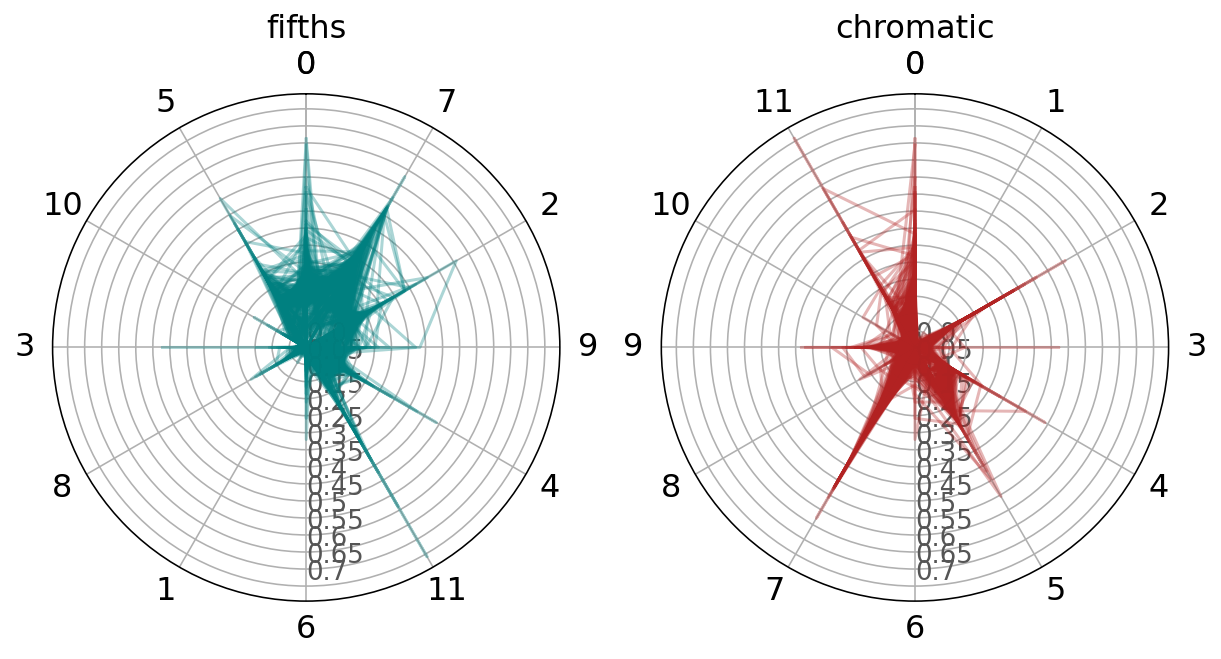

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10,8), subplot_kw={"polar": True})

for ax, ord in zip(axes, ("fifths", "chromatic")):
    for i in range(N):
        plot_area(piece_id=i, data=samples, ax=ax, ordering=ord, fill=False, draw=True)

#     ax.get_legend().remove()